In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Load & Clean Data

#### DXA sleep

In [2]:
dxa_actigraphy_df = pd.read_excel('/Users/thomasgooding/Desktop/Rutgers_Sleep_Cannabis_Alcohol_study/scored_summary_actigraphy_data/DXA_Sleep_nocturnal_actigraphy_scored_df.xlsx')
## clean column names
dxa_actigraphy_df.columns = dxa_actigraphy_df.columns.str.lower().str.strip()
dxa_actigraphy_df.columns = dxa_actigraphy_df.columns.str.replace(' ', '_')
dxa_actigraphy_df.drop(0, axis=0, inplace=True)
dxa_actigraphy_df.rename(columns={'subjectid': 'subject_id', 'offwrist':'off_wrist', '%offwrist':'pcn_off_wrist'}, inplace=True)
dxa_actigraphy_df['study'] = 'DXA'
dxa_actigraphy_df.reset_index(drop=True, inplace=True)
dxa_actigraphy_df['semester'] = np.nan ## added to align columns for future merge
# dxa_actigraphy_df['user_study_id'] = dxa_actigraphy_df['study'] + (dxa_actigraphy_df['subject_id'].astype(str))
dxa_actigraphy_df['subject_id'] = dxa_actigraphy_df['subject_id'].apply(lambda x: f'DXA_{x:03d}')

dxa_actigraphy_df.head()

,subject_id,passcode,interval_type,interval#,night,start_date,start_day,start_time,end_date,end_day,...,#wakebouts,avg_wake_b,sleep_time,%_sleep,#sleepbouts,avgsleepb,fragmentation,flag_actigraph,study,semester
0,DXA_001,DXA001,Sleep,1,Friday,2019-09-20 00:00:00,Fri,23:21:00,2019-09-21 00:00:00,Sat,...,19,1.47,487,94.56,20,24.35,20.28,NaN,DXA,NaN
1,DXA_001,DXA001,Sleep,2,Saturday,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EXCLUDED - >15% of the day off-wrist,DXA,NaN
2,DXA_001,DXA001,Sleep,3,Sunday,2019-09-22 00:00:00,Sun,21:42:00,2019-09-23 00:00:00,Mon,...,27,1.41,610,94.14,28,21.79,20.75,NaN,DXA,NaN
3,DXA_001,DXA001,Sleep,4,Monday,2019-09-23 00:00:00,Mon,22:21:00,2019-09-24 00:00:00,Tue,...,26,2.15,512,90.14,27,18.96,28.54,NaN,DXA,NaN
4,DXA_001,DXA001,Sleep,5,Tuesday,2019-09-25 00:00:00,Wed,00:29:00,2019-09-25 00:00:00,Wed,...,13,1.54,451,95.75,14,32.21,17.8,NaN,DXA,NaN


In [3]:
dxa_actigraphy_df.columns

Index(['subject_id', 'passcode', 'interval_type', 'interval#', 'night',
       'start_date', 'start_day', 'start_time', 'end_date', 'end_day',
       'end_time', 'duration', 'off_wrist', 'pcn_off_wrist', 'totalac',
       'avg_ac/min', 'max_ac', 'onsetlat', 'eff', 'waso', 'waketime', '%wake',
       '#wakebouts', 'avg_wake_b', 'sleep_time', '%_sleep', '#sleepbouts',
       'avgsleepb', 'fragmentation', 'flag_actigraph', 'study', 'semester'],
      dtype='object')

#### siesta 2

In [4]:
siesta2_actigraphy_df = pd.read_excel('/Users/thomasgooding/Desktop/Rutgers_Sleep_Cannabis_Alcohol_study/scored_summary_actigraphy_data/Siesta2_NocturnalActigraphy_Phase1_Dataset.xlsx', header=1)
## clean column names
siesta2_actigraphy_df.columns = siesta2_actigraphy_df.columns.str.lower().str.strip()
siesta2_actigraphy_df.columns = siesta2_actigraphy_df.columns.str.replace(' ', '_')
siesta2_actigraphy_df.rename(columns = {'%offwrist': 'pcn_off_wrist', 'offwrist':'off_wrist'}, inplace=True)
siesta2_actigraphy_df.drop(0, axis=0, inplace=True)
siesta2_actigraphy_df.drop(['analysis_name', 'unnamed:_31', 'unnamed:_32' ], axis=1, inplace=True)
siesta2_actigraphy_df['study'] = 'siesta2'
siesta2_actigraphy_df.reset_index(drop=True, inplace=True)
siesta2_actigraphy_df['passcode'] = np.nan ## added to align columns for future merge
siesta2_actigraphy_df['subject_id'] = siesta2_actigraphy_df['subject_id'].apply(lambda x: f'siesta2_{x:03d}')

siesta2_actigraphy_df.head()

,semester,subject_id,interval_type,interval#,night,start_date,start_day,start_time,end_date,end_day,...,#wakebouts,avg_wake_b,sleep_time,%_sleep,#sleepbouts,avgsleepb,fragmentation,flag_actigraph,study,passcode
0,Spring 2020,siesta2_103,Sleep,1,Wednesday,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EXCLUDED - >15% of the day off-wrist,siesta2,NaN
1,Spring 2020,siesta2_103,Sleep,2,Thursday,2020-01-31 00:00:00,Fri,00:45:00,2020-01-31 00:00:00,Fri,...,22,3.18,468,86.99,23,20.35,31.59,NaN,siesta2,NaN
2,Spring 2020,siesta2_103,Sleep,3,Friday,2020-02-01 00:00:00,Sat,01:33:00,2020-02-01 00:00:00,Sat,...,22,3.5,424,84.63,23,18.43,50.36,NaN,siesta2,NaN
3,Spring 2020,siesta2_103,Sleep,4,Saturday,2020-02-02 00:00:00,Sun,01:09:00,2020-02-02 00:00:00,Sun,...,27,2.89,460,85.5,28,16.43,62.83,NaN,siesta2,NaN
4,Spring 2020,siesta2_103,Sleep,5,Sunday,2020-02-03 00:00:00,Mon,01:19:00,2020-02-03 00:00:00,Mon,...,24,3.21,332,81.17,25,13.28,51.18,NaN,siesta2,NaN


#### SNA

In [5]:
sna_study1_actigraphy_df = pd.read_excel('/Users/thomasgooding/Desktop/Rutgers_Sleep_Cannabis_Alcohol_study/scored_summary_actigraphy_data/SNA_study1_Actigraphy Nocturnal Sleep Study 1 - Dataset.xlsx')
## clean column names
sna_study1_actigraphy_df.columns = sna_study1_actigraphy_df.columns.str.lower().str.strip()
sna_study1_actigraphy_df.columns = sna_study1_actigraphy_df.columns.str.replace(' ', '_')
sna_study1_actigraphy_df.drop(0, axis=0, inplace=True)
sna_study1_actigraphy_df.rename(columns= {'analysis_name': 'subject_id', 'off-wrist':'off_wrist', '%off-wrist':'pcn_off_wrist'}, inplace=True)
sna_study1_actigraphy_df['subject_id'] = sna_study1_actigraphy_df['subject_id'].str.replace(r'\D', '', regex=True).astype(str)
sna_study1_actigraphy_df['study'] = 'SNA_1'
sna_study1_actigraphy_df.reset_index(drop=True, inplace=True)
sna_study1_actigraphy_df['night'] = np.nan
sna_study1_actigraphy_df['subject_id'] = sna_study1_actigraphy_df['subject_id'].apply(lambda x: f'SNA1_{x}')


sna_study1_actigraphy_df.head()

,semester,subject_id,passcode,interval_type,interval#,start_date,start_day,start_time,end_date,end_day,...,#wakebouts,avg_wake_b,sleep_time,%_sleep,#sleepbouts,avgsleepb,fragmentation,flag_actigraph,study,night
0,Summer 2023,SNA1_154801,Lynn,Sleep,1,2023-07-19 00:00:00,Wed,02:16:00,2023-07-19 00:00:00,Wed,...,27,2.78,390,83.87,28,13.93,29.46,NaN,SNA_1,NaN
1,Summer 2023,SNA1_154801,Lynn,Sleep,2,2023-07-20 00:00:00,Thu,01:20:00,2023-07-20 00:00:00,Thu,...,41,2.12,533,85.97,42,12.69,31.47,NaN,SNA_1,NaN
2,Summer 2023,SNA1_154801,Lynn,Sleep,3,2023-07-21 00:00:00,Fri,03:30:00,2023-07-21 00:00:00,Fri,...,18,3.89,250,78.13,19,13.16,50.42,NaN,SNA_1,NaN
3,Summer 2023,SNA1_154801,Lynn,Sleep,4,2023-07-22 00:00:00,Sat,04:19:00,2023-07-22 00:00:00,Sat,...,21,2.52,341,86.55,22,15.5,30.63,NaN,SNA_1,NaN
4,Summer 2023,SNA1_154801,Lynn,Sleep,5,2023-07-23 00:00:00,Sun,01:51:00,2023-07-23 00:00:00,Sun,...,29,2.45,373,84.01,30,12.43,24.88,NaN,SNA_1,NaN


#### SPU

In [6]:
spu_study1_actigraphy_df = pd.read_excel('/Users/thomasgooding/Desktop/Rutgers_Sleep_Cannabis_Alcohol_study/scored_summary_actigraphy_data/SPU_study1_Actigraphy Nocturnal Sleep Study 1 - Dataset.xlsx', header=0)
## clean column names
spu_study1_actigraphy_df.columns = spu_study1_actigraphy_df.columns.str.lower().str.strip()
spu_study1_actigraphy_df.columns = spu_study1_actigraphy_df.columns.str.replace(' ', '_')
spu_study1_actigraphy_df['study'] = 'SPU_1'
spu_study1_actigraphy_df.rename(columns= {'analysis_name': 'subject_id','off-wrist':'off_wrist', '%off-wrist':'pcn_off_wrist'}, inplace=True)
spu_study1_actigraphy_df['subject_id'] = spu_study1_actigraphy_df['subject_id'].str.replace(r'\D', '', regex=True)
spu_study1_actigraphy_df.drop(0, axis=0, inplace=True)
spu_study1_actigraphy_df.reset_index(drop=True, inplace=True)
spu_study1_actigraphy_df['night'] = np.nan
spu_study1_actigraphy_df['subject_id'] = spu_study1_actigraphy_df['subject_id'].apply(lambda x: f'SPU1_{x}')

spu_study1_actigraphy_df.head()

,semester,subject_id,passcode,interval_type,interval#,start_date,start_day,start_time,end_date,end_day,...,#wakebouts,avg_wake_b,sleep_time,%_sleep,#sleepbouts,avgsleepb,fragmentation,flag_actigraph,study,night
0,Spring 2022,SPU1_154314,Tobolsk,Sleep,1,2022-01-26 00:00:00,Wed,01:37:00,2022-01-26 00:00:00,Wed,...,27,1.41,407,91.46,28,14.54,24.26,NaN,SPU_1,NaN
1,Spring 2022,SPU1_154314,Tobolsk,Sleep,2,2022-01-27 00:00:00,Thu,02:55:00,2022-01-27 00:00:00,Thu,...,19,1.53,275,90.46,20,13.75,21.85,NaN,SPU_1,NaN
2,Spring 2022,SPU1_154314,Tobolsk,Sleep,3,2022-01-28 00:00:00,Fri,03:00:00,2022-01-28 00:00:00,Fri,...,8,1.75,271,95.09,9,30.11,7.02,NaN,SPU_1,NaN
3,Spring 2022,SPU1_154314,Tobolsk,Sleep,4,2022-01-29 00:00:00,Sat,01:51:00,2022-01-29 00:00:00,Sat,...,28,1.82,427,89.33,30,14.23,19.72,NaN,SPU_1,NaN
4,Spring 2022,SPU1_154314,Tobolsk,Sleep,5,2022-01-30 00:00:00,Sun,01:34:00,2022-01-30 00:00:00,Sun,...,21,1.81,285,88.24,22,12.95,17.62,NaN,SPU_1,NaN


In [7]:
dxa_cols = list(dxa_actigraphy_df.columns.str.strip())
siesta_cols = list(siesta2_actigraphy_df.columns.str.strip())
sna_cols = list(sna_study1_actigraphy_df.columns.str.strip())
spu_cols = list(spu_study1_actigraphy_df.columns.str.strip())

In [8]:
study_col_names = pd.DataFrame({
'DXA_cols': pd.Series(dxa_cols),
'siesta2_cols': pd.Series(siesta_cols),
'sna_1_cols': pd.Series(sna_cols),
'spu_1_cols': pd.Series(spu_cols)
})

study_col_names.columns = study_col_names.columns.str.strip()
# study_col_names_filtered.head()

In [9]:
study_col_names_sorted = study_col_names.sort_values(['DXA_cols', 'siesta2_cols', 'sna_1_cols', 'spu_1_cols'], ascending = [False, False, False, False]).reset_index(drop=True)

study_col_names_filtered = study_col_names_sorted.astype(str)

# study_col_names_filtered.replace('_','', inplace=True, regex=True)
# ## reconciling name convention differences + irrelevant columns
study_col_names_filtered.replace(to_replace= {'eff':'sleep_efficiency', '%':'pcn_', 'lat':'_latency', 'offwrist':'off_wrist', 'unnamed:_31': np.nan, 'off-wrist': 'off_wrist', 'unnamed:_32': np.nan, 'nan': np.nan},regex=True, inplace=True )

study_col_names_filtered.sort_values('DXA_cols', ascending=True)


,DXA_cols,siesta2_cols,sna_1_cols,spu_1_cols
31,#sleepbouts,#sleepbouts,#sleepbouts,#sleepbouts
30,#wakebouts,#wakebouts,#wakebouts,#wakebouts
27,avg_ac/min,avg_ac/min,avg_ac/min,avg_ac/min
26,avg_wake_b,avg_wake_b,avg_wake_b,avg_wake_b
25,avgsleepb,avgsleepb,avgsleepb,avgsleepb
24,duration,duration,duration,duration
22,end_date,end_date,end_date,end_date
21,end_day,end_day,end_day,end_day
20,end_time,end_time,end_time,end_time
19,flag_actigraph,flag_actigraph,flag_actigraph,flag_actigraph


## Merging Prep steps

- Finding which columns are missing from each dataframe. Add mising columns to each df, respectively, then merge all study actigraphy together. 

- re-run these first 4 cells after adding new columns to verify which are still missing (if any)

In [10]:
DXA_min_sna = set(study_col_names_filtered['DXA_cols'].values) - set(study_col_names_filtered['sna_1_cols'].values)

## columns in DXA sleep not in sna_1/spu_1

print(f'{DXA_min_sna} in DXA but not sna/spu')
print('added')

set() in DXA but not sna/spu
added


In [11]:
sna_min_DXA = set(study_col_names_filtered['sna_1_cols'].values) - set(study_col_names_filtered['DXA_cols'].values)

## columns in sna_1/spu_1 not in DXA sleep
print(f'{sna_min_DXA} in sna/spu and not DXA')
print('added')

set() in sna/spu and not DXA
added


In [12]:
sna_min_siesta2 = set(study_col_names_filtered['sna_1_cols'].values) - set(study_col_names_filtered['siesta2_cols'].values)

## Cols in siesta 2 that aren't in sna_1 or spu_1
print(f'{sna_min_siesta2} cols in sna/spu and not siesta2')
print('added')

set() cols in sna/spu and not siesta2
added


In [13]:
DXA_min_snaspu = set(study_col_names_filtered['siesta2_cols'].values) - set(study_col_names_filtered['sna_1_cols'].values)

print(f'{DXA_min_snaspu} columns are in DXA sleep but not sna/spu')
print('added')

set() columns are in DXA sleep but not sna/spu
added


In [14]:
siesta2_min_DXA = set(study_col_names_filtered['siesta2_cols'].values) - set(study_col_names_filtered['DXA_cols'].values)

print(f'{siesta2_min_DXA} columns are in siesta2  but not DXA')
print('added')
## which cols aren't in DXA that are in siesta2_cols


set() columns are in siesta2  but not DXA
added


In [15]:
DXA_min_siesta2 = set(study_col_names_filtered['DXA_cols'].values) - set(study_col_names_filtered['siesta2_cols'].values)

## which cols are in DXA that aren't in siesta2
print(f'{DXA_min_siesta2} in DXA but not siesta 2')
print('added')

set() in DXA but not siesta 2
added


In [16]:
sna_min_DXA = set(study_col_names_filtered['sna_1_cols'].values) - set(study_col_names_filtered['DXA_cols'].values)
## which cols are in sna_1/spu_1 that aren't in DXA
print(f'{sna_min_DXA} in sna/spu but not DXA')
print('added')

set() in sna/spu but not DXA
added


## Merge datasets

In [17]:
sleep_merged_df = pd.concat([dxa_actigraphy_df,siesta2_actigraphy_df,sna_study1_actigraphy_df,spu_study1_actigraphy_df], axis=0).reset_index(drop=True)

## Export merged dataset

In [29]:
# sleep_merged_df.to_excel('sleep_merged_df_062326.xlsx')


# Setting up Time-series data

In [19]:
import datetime

test_df = sleep_merged_df.copy()
sleep_merged_df.columns


Index(['subject_id', 'passcode', 'interval_type', 'interval#', 'night',
       'start_date', 'start_day', 'start_time', 'end_date', 'end_day',
       'end_time', 'duration', 'off_wrist', 'pcn_off_wrist', 'totalac',
       'avg_ac/min', 'max_ac', 'onsetlat', 'eff', 'waso', 'waketime', '%wake',
       '#wakebouts', 'avg_wake_b', 'sleep_time', '%_sleep', '#sleepbouts',
       'avgsleepb', 'fragmentation', 'flag_actigraph', 'study', 'semester'],
      dtype='object')

In [20]:
time_vars = ['night', 'start_date', 'start_day', 'start_time', 'end_date', 'end_time']

sleep_merged_df[time_vars].head()

,night,start_date,start_day,start_time,end_date,end_time
0,Friday,2019-09-20 00:00:00,Fri,23:21:00,2019-09-21 00:00:00,07:56:00
1,Saturday,NaN,NaN,NaN,NaN,NaN
2,Sunday,2019-09-22 00:00:00,Sun,21:42:00,2019-09-23 00:00:00,08:30:00
3,Monday,2019-09-23 00:00:00,Mon,22:21:00,2019-09-24 00:00:00,07:49:00
4,Tuesday,2019-09-25 00:00:00,Wed,00:29:00,2019-09-25 00:00:00,08:20:00


In [21]:
time_cols = ['start_time', 'end_time']
date_cols = ['start_date', 'end_date']
## convert columns to time series data
sleep_merged_df['start_date'] = pd.to_datetime(sleep_merged_df['start_date'], errors='coerce').dt.normalize()
sleep_merged_df['end_date'] = pd.to_datetime(sleep_merged_df['end_date'], errors='coerce').dt.normalize()
sleep_merged_df['start_time'] = pd.to_datetime(sleep_merged_df['start_time'], format= '%H:%M:%S', errors='coerce').dt.time
sleep_merged_df['end_time'] = pd.to_datetime(sleep_merged_df['end_time'], format= '%H:%M:%S', errors='coerce').dt.time

## merge start date + start time
sleep_merged_df['start_datetime'] = pd.to_datetime(
    sleep_merged_df['start_date'].dt.strftime('%Y-%m-%d')
    + ' '
    + sleep_merged_df['start_time'].astype(str)
)
## Merge end date + end time
sleep_merged_df['end_datetime'] = pd.to_datetime(
    sleep_merged_df['end_date'].dt.strftime('%Y-%m-%d')
    + ' '
    + sleep_merged_df['end_time'].astype(str)
)

sleep_merged_df[['start_time', 'end_time', 'start_date', 'end_date', 'start_datetime', 'end_datetime']].head()

,start_time,end_time,start_date,end_date,start_datetime,end_datetime
0,23:21:00,07:56:00,2019-09-20,2019-09-21,2019-09-20 23:21:00,2019-09-21 07:56:00
1,NaT,NaT,NaT,NaT,NaT,NaT
2,21:42:00,08:30:00,2019-09-22,2019-09-23,2019-09-22 21:42:00,2019-09-23 08:30:00
3,22:21:00,07:49:00,2019-09-23,2019-09-24,2019-09-23 22:21:00,2019-09-24 07:49:00
4,00:29:00,08:20:00,2019-09-25,2019-09-25,2019-09-25 00:29:00,2019-09-25 08:20:00


In [22]:
sleep_merged_df['time_diff'] = (sleep_merged_df['end_datetime'] - sleep_merged_df['start_datetime'])

sleep_merged_df['tst_min'] = sleep_merged_df['time_diff'].dt.total_seconds()/60

sleep_merged_df['sleep_mid_dt'] = sleep_merged_df['start_datetime'] + ((sleep_merged_df['end_datetime'] - sleep_merged_df['start_datetime'])/2)

sleep_merged_df['sleep_onset_plus4h'] = sleep_merged_df['start_datetime'] + pd.Timedelta(hours=4)


sleep_merged_df.head()

,subject_id,passcode,interval_type,interval#,night,start_date,start_day,start_time,end_date,end_day,...,fragmentation,flag_actigraph,study,semester,start_datetime,end_datetime,time_diff,tst_min,sleep_mid_dt,sleep_onset_plus4h
0,DXA_001,DXA001,Sleep,1,Friday,2019-09-20,Fri,23:21:00,2019-09-21,Sat,...,20.28,NaN,DXA,NaN,2019-09-20 23:21:00,2019-09-21 07:56:00,0 days 08:35:00,515.0,2019-09-21 03:38:30,2019-09-21 03:21:00
1,DXA_001,DXA001,Sleep,2,Saturday,NaT,NaN,NaT,NaT,NaN,...,NaN,EXCLUDED - >15% of the day off-wrist,DXA,NaN,NaT,NaT,NaT,NaN,NaT,NaT
2,DXA_001,DXA001,Sleep,3,Sunday,2019-09-22,Sun,21:42:00,2019-09-23,Mon,...,20.75,NaN,DXA,NaN,2019-09-22 21:42:00,2019-09-23 08:30:00,0 days 10:48:00,648.0,2019-09-23 03:06:00,2019-09-23 01:42:00
3,DXA_001,DXA001,Sleep,4,Monday,2019-09-23,Mon,22:21:00,2019-09-24,Tue,...,28.54,NaN,DXA,NaN,2019-09-23 22:21:00,2019-09-24 07:49:00,0 days 09:28:00,568.0,2019-09-24 03:05:00,2019-09-24 02:21:00
4,DXA_001,DXA001,Sleep,5,Tuesday,2019-09-25,Wed,00:29:00,2019-09-25,Wed,...,17.8,NaN,DXA,NaN,2019-09-25 00:29:00,2019-09-25 08:20:00,0 days 07:51:00,471.0,2019-09-25 04:24:30,2019-09-25 04:29:00


# Final Data Exports

- finished updating time-series columns and merging datasets

**data to export:** 
1. sleep_merged_cleaned_df 
- includes cleaned dataset for later analysis

2. sleep_data_to_drop
- includes which columns will be excluded in the actigraphy data datasets once they're merged

In [23]:
sleep_merged_df.to_excel('sleep_merged_df_cleaned_062326.xlsx')

In [24]:
sleep_data_to_drop_df = sleep_merged_df[~sleep_merged_df['flag_actigraph'].isnull()].copy().reset_index(drop=True)

sleep_data_to_drop_df.head()
sleep_data_to_drop_df.to_excel('sleep_data_to_drop_df.xlsx')

## filter out rows of data that don't include sleep data (will use for filtering actigraphy data later)

In [30]:
sleep_merged_df.head()

,subject_id,passcode,interval_type,interval#,night,start_date,start_day,start_time,end_date,end_day,...,fragmentation,flag_actigraph,study,semester,start_datetime,end_datetime,time_diff,tst_min,sleep_mid_dt,sleep_onset_plus4h
0,DXA_001,DXA001,Sleep,1,Friday,2019-09-20,Fri,23:21:00,2019-09-21,Sat,...,20.28,NaN,DXA,NaN,2019-09-20 23:21:00,2019-09-21 07:56:00,0 days 08:35:00,515.0,2019-09-21 03:38:30,2019-09-21 03:21:00
1,DXA_001,DXA001,Sleep,2,Saturday,NaT,NaN,NaT,NaT,NaN,...,NaN,EXCLUDED - >15% of the day off-wrist,DXA,NaN,NaT,NaT,NaT,NaN,NaT,NaT
2,DXA_001,DXA001,Sleep,3,Sunday,2019-09-22,Sun,21:42:00,2019-09-23,Mon,...,20.75,NaN,DXA,NaN,2019-09-22 21:42:00,2019-09-23 08:30:00,0 days 10:48:00,648.0,2019-09-23 03:06:00,2019-09-23 01:42:00
3,DXA_001,DXA001,Sleep,4,Monday,2019-09-23,Mon,22:21:00,2019-09-24,Tue,...,28.54,NaN,DXA,NaN,2019-09-23 22:21:00,2019-09-24 07:49:00,0 days 09:28:00,568.0,2019-09-24 03:05:00,2019-09-24 02:21:00
4,DXA_001,DXA001,Sleep,5,Tuesday,2019-09-25,Wed,00:29:00,2019-09-25,Wed,...,17.8,NaN,DXA,NaN,2019-09-25 00:29:00,2019-09-25 08:20:00,0 days 07:51:00,471.0,2019-09-25 04:24:30,2019-09-25 04:29:00


<Axes: xlabel='interval#', ylabel='Count'>

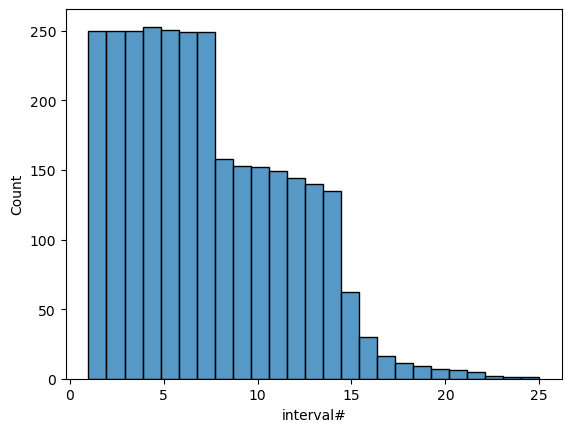

In [25]:
sns.histplot(data=sleep_merged_df, x='interval#')

<Axes: xlabel='sleep_time', ylabel='Count'>

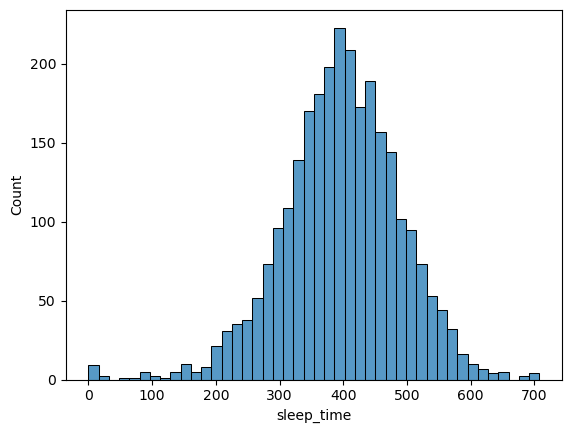

In [26]:
sns.histplot(data=sleep_merged_df, x='sleep_time')

In [27]:
sleep_merged_df.columns.duplicated().any()

np.False_

In [28]:
list(sleep_merged_df.columns)

['subject_id',
 'passcode',
 'interval_type',
 'interval#',
 'night',
 'start_date',
 'start_day',
 'start_time',
 'end_date',
 'end_day',
 'end_time',
 'duration',
 'off_wrist',
 'pcn_off_wrist',
 'totalac',
 'avg_ac/min',
 'max_ac',
 'onsetlat',
 'eff',
 'waso',
 'waketime',
 '%wake',
 '#wakebouts',
 'avg_wake_b',
 'sleep_time',
 '%_sleep',
 '#sleepbouts',
 'avgsleepb',
 'fragmentation',
 'flag_actigraph',
 'study',
 'semester',
 'start_datetime',
 'end_datetime',
 'time_diff',
 'tst_min',
 'sleep_mid_dt',
 'sleep_onset_plus4h']